In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Set consistent style for all charts
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

# Configure for publication-quality output
plt.rcParams['figure.figsize'] = [10, 6]
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Load your data
df = pd.read_csv('data/processed/master_dataset.csv')
print(f"Loaded {len(df)} rows")

Loaded 150 rows


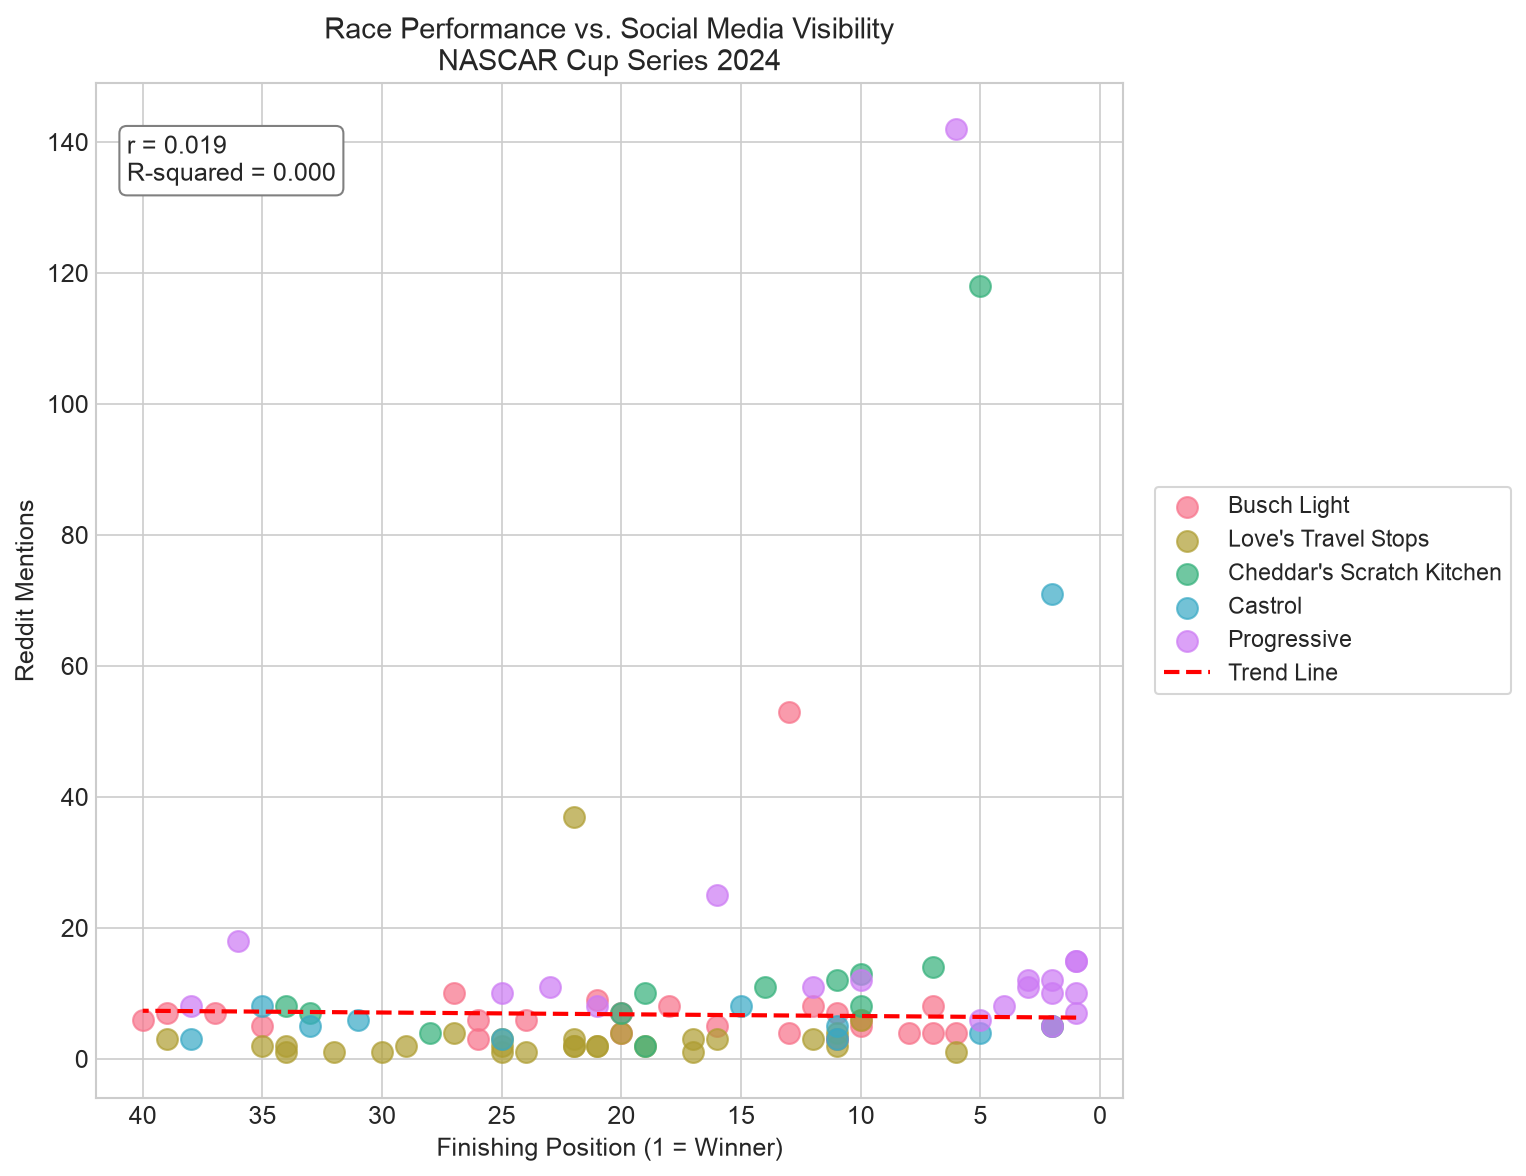

Chart saved: scatter_finish_vs_reddit.png


In [2]:
# Create figure
fig, ax = plt.subplots(figsize=(13, 8))

# Get unique sponsors for color coding
sponsors = [s for s in df['primary_sponsor'].unique() if s != 'Other/Unknown']
colors = sns.color_palette("husl", len(sponsors))

# Plot each sponsor with different color
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax.scatter(
        sponsor_data['finish_position'],
        sponsor_data['reddit_mention_count'],
        label=sponsor,
        alpha=0.7,
        s=100,
        c=[colors[i]]
    )

# Add trend line for overall data
z = np.polyfit(df['finish_position'], df['reddit_mention_count'], 1)
p = np.poly1d(z)
x_line = np.linspace(df['finish_position'].min(), df['finish_position'].max(), 100)
ax.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')

# Calculate and display R-squared
correlation = df['finish_position'].corr(df['reddit_mention_count'])
r_squared = correlation ** 2

# Stat box in the top-left corner — the emptiest region of this particular
# scatter (the high-Reddit outliers all sit toward the right/top-right), so
# it won't sit on top of data the way the old top-right placement did.
ax.annotate(
    f'r = {correlation:.3f}\nR-squared = {r_squared:.3f}',
    xy=(0.03, 0.95),
    xycoords='axes fraction',
    fontsize=12,
    ha='left',
    va='top',
    bbox=dict(boxstyle='round', facecolor='white', edgecolor='gray')
)

# Customize chart
ax.set_xlabel('Finishing Position (1 = Winner)', fontsize=12)
ax.set_ylabel('Reddit Mentions', fontsize=12)
ax.set_title('Race Performance vs. Social Media Visibility\nNASCAR Cup Series 2024', fontsize=14)
ax.invert_xaxis()  # Lower position numbers on left (better finishes)

# Legend fully outside the plot area (not just nudged past the edge) so it
# never overlaps a data point, regardless of where points happen to fall.
ax.legend(loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=True, fontsize=11)

fig.tight_layout(rect=[0, 0, 0.8, 1])
plt.savefig('data/plots/scatter_finish_vs_reddit.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: scatter_finish_vs_reddit.png")

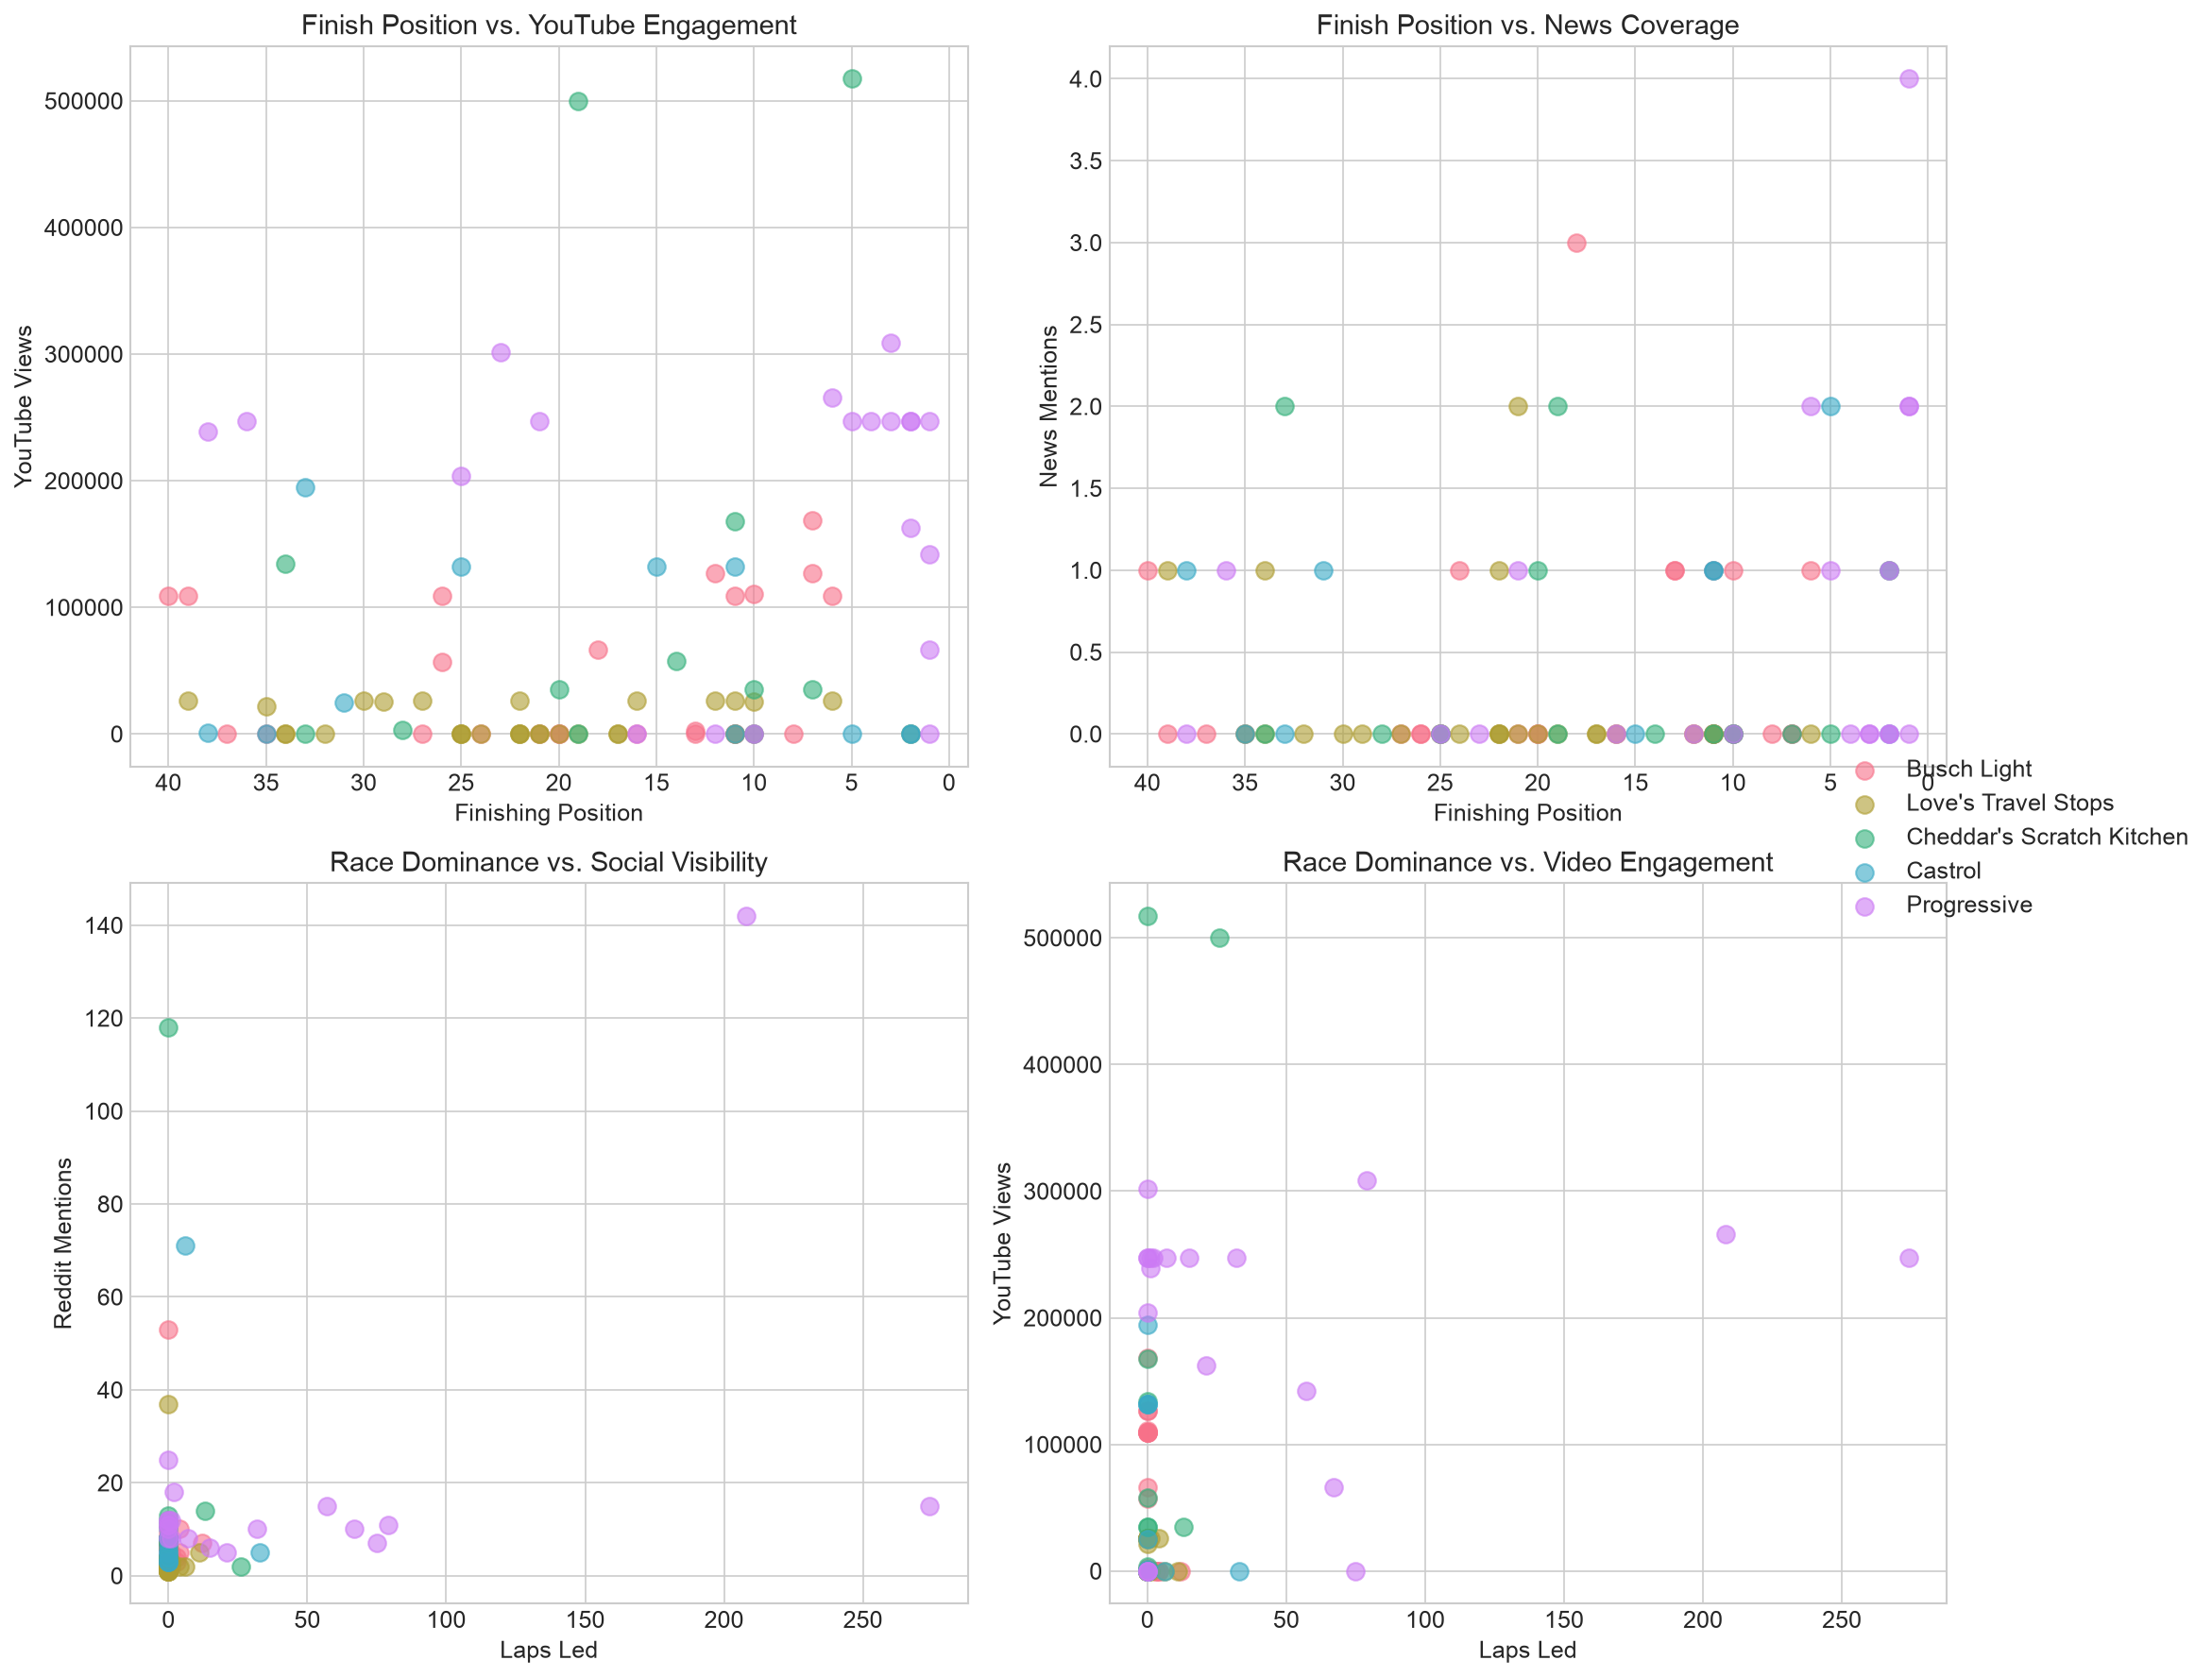

Chart saved: scatter_grid_all_metrics.png


In [3]:
# Create a 2x2 grid of scatter plots
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Finish Position vs YouTube Views
ax1 = axes[0, 0]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax1.scatter(sponsor_data['finish_position'], sponsor_data['youtube_total_view_count'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax1.set_xlabel('Finishing Position')
ax1.set_ylabel('YouTube Views')
ax1.set_title('Finish Position vs. YouTube Engagement')
ax1.invert_xaxis()

# Plot 2: Finish Position vs News Mentions
ax2 = axes[0, 1]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax2.scatter(sponsor_data['finish_position'], sponsor_data['news_total_mentions'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax2.set_xlabel('Finishing Position')
ax2.set_ylabel('News Mentions')
ax2.set_title('Finish Position vs. News Coverage')
ax2.invert_xaxis()

# Plot 3: Laps Led vs Reddit Mentions
ax3 = axes[1, 0]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax3.scatter(sponsor_data['laps_led'], sponsor_data['reddit_mention_count'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax3.set_xlabel('Laps Led')
ax3.set_ylabel('Reddit Mentions')
ax3.set_title('Race Dominance vs. Social Visibility')

# Plot 4: Laps Led vs YouTube Views
ax4 = axes[1, 1]
for i, sponsor in enumerate(sponsors):
    sponsor_data = df[df['primary_sponsor'] == sponsor]
    ax4.scatter(sponsor_data['laps_led'], sponsor_data['youtube_total_view_count'],
                alpha=0.6, s=80, c=[colors[i]], label=sponsor)
ax4.set_xlabel('Laps Led')
ax4.set_ylabel('YouTube Views')
ax4.set_title('Race Dominance vs. Video Engagement')

# Add shared legend
handles, labels = ax1.get_legend_handles_labels()
fig.legend(handles, labels, loc='center right', bbox_to_anchor=(1.12, 0.5))

plt.tight_layout()
plt.savefig('data/plots/scatter_grid_all_metrics.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: scatter_grid_all_metrics.png")

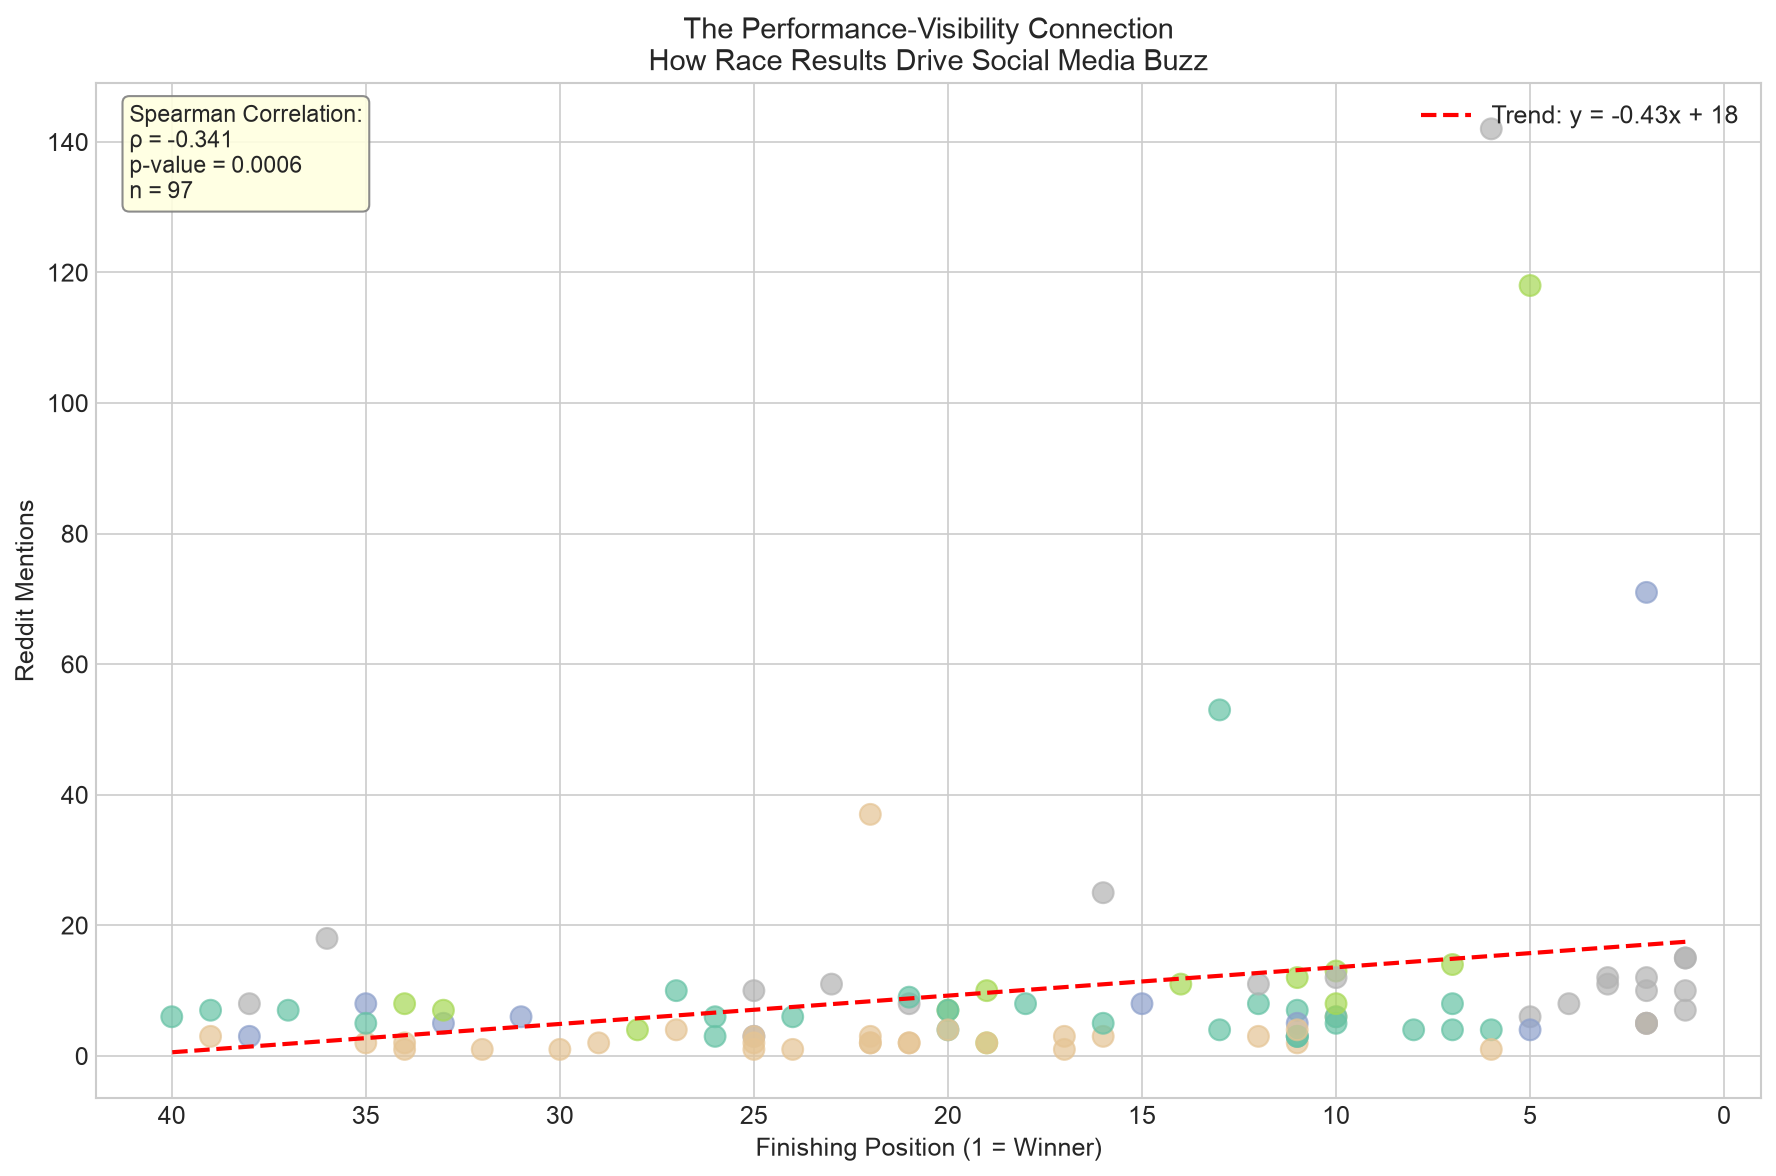

In [4]:
# Enhanced scatter plot with regression statistics
# Filter out "Other/Unknown" the same way statistical_analysis.ipynb does —
# those rows are aggregated placeholders (reddit_mention_count = 0 for all of
# them) and otherwise dilute the correlation.
plot_df = df[df['primary_sponsor'] != 'Other/Unknown']

fig, ax = plt.subplots(figsize=(12, 8))

# Scatter plot with all data
scatter = ax.scatter(
    plot_df['finish_position'],
    plot_df['reddit_mention_count'],
    c=plot_df['primary_sponsor'].astype('category').cat.codes,
    cmap='Set2',
    alpha=0.7,
    s=100
)

# Spearman, not Pearson — reddit_mention_count is skewed with real outliers
# (confirmed via histogram + Shapiro-Wilk in statistical_analysis.ipynb), so
# rank correlation is the appropriate test here, same as that notebook uses.
rho, p_value = stats.spearmanr(plot_df['finish_position'], plot_df['reddit_mention_count'])

# linregress is still fine purely for drawing a visual trend line (least-squares
# fit through the points) — it's just no longer the basis for the reported stats.
slope, intercept, _, _, _ = stats.linregress(plot_df['finish_position'], plot_df['reddit_mention_count'])

# Plot regression line
x_line = np.linspace(plot_df['finish_position'].min(), plot_df['finish_position'].max(), 100)
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'Trend: y = {slope:.2f}x + {intercept:.0f}')

# Add annotation box with statistics
stats_text = f'Spearman Correlation:\n'
stats_text += f'ρ = {rho:.3f}\n'
stats_text += f'p-value = {p_value:.4f}\n'
stats_text += f'n = {len(plot_df)}'

ax.annotate(
    stats_text,
    xy=(0.02, 0.98),
    xycoords='axes fraction',
    fontsize=11,
    va='top',
    ha='left',
    bbox=dict(boxstyle='round', facecolor='lightyellow', edgecolor='gray', alpha=0.9)
)

ax.set_xlabel('Finishing Position (1 = Winner)', fontsize=12)
ax.set_ylabel('Reddit Mentions', fontsize=12)
ax.set_title('The Performance-Visibility Connection\nHow Race Results Drive Social Media Buzz', fontsize=14)
ax.invert_xaxis()
ax.legend(loc='upper right')

plt.tight_layout()
plt.savefig('data/plots/scatter_with_regression.png', dpi=150)
plt.show()

[0.47950696 0.31207298 0.20842006]
[0.67023397 0.36868116 0.64409675]


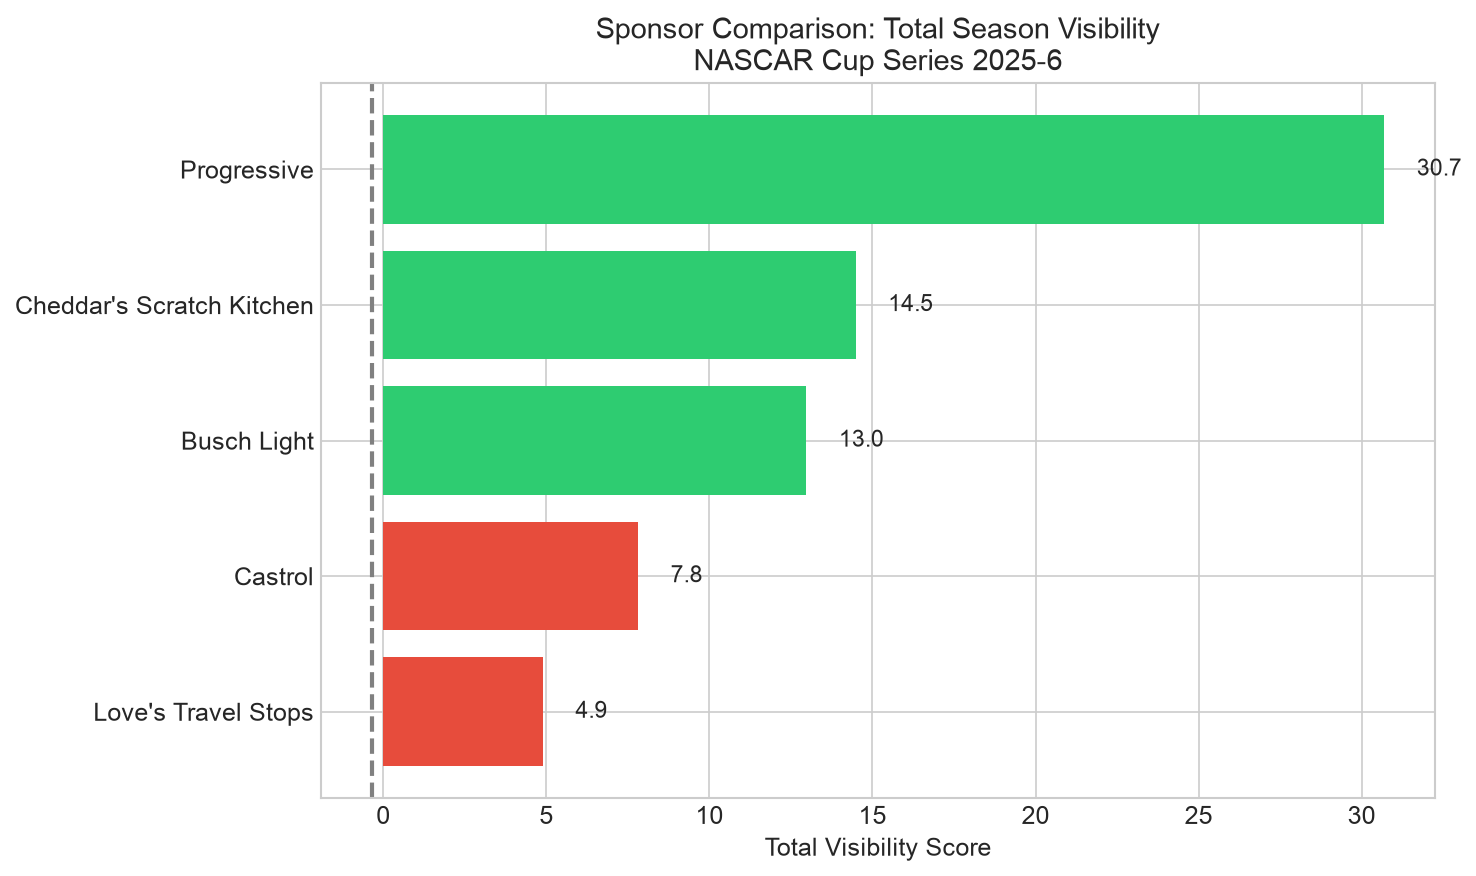

Chart saved: bar_sponsor_visibility.png


In [5]:
# Calculate average visibility metrics by sponsor
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import math as m

sponsor_summary = df[df['primary_sponsor'] != 'Other/Unknown']

# Create composite visibility score for comparison
# (Normalize each metric to 0-100 scale, then average)
sponsor_summary['Reddit_Normalized'] = (
    (sponsor_summary['reddit_mention_count'] - sponsor_summary['reddit_mention_count'].mean()) /
    (sponsor_summary['reddit_mention_count'].std())
)
sponsor_summary['YouTube_Normalized'] = (
    (sponsor_summary['youtube_total_view_count'] - sponsor_summary['youtube_total_view_count'].mean()) /
    (sponsor_summary['youtube_total_view_count'].std())
)
sponsor_summary['News_Normalized'] = (
    (sponsor_summary['news_total_mentions'] - sponsor_summary['news_total_mentions'].mean()) /
    (sponsor_summary['news_total_mentions'].std())
)

X = sponsor_summary[['Reddit_Normalized', 'News_Normalized', 'YouTube_Normalized']]
X_scaled = StandardScaler().fit_transform(X)

pca = PCA()
pca.fit(X_scaled)
print(pca.explained_variance_ratio_)   # how much each PC explains
print(pca.components_[0])              # loadings for PC1 — your data-driven weights

# add a normalization to account for sample size
news_samples = 36 #num of nonzero rows
reddit_samples = 222
yt_samples = 137


sponsor_summary['Visibility_Score'] = (
    sponsor_summary['Reddit_Normalized'] * abs(pca.components_[0][0]) * m.sqrt(222/223)+ 
    sponsor_summary['YouTube_Normalized'] * abs(pca.components_[0][2]) *  m.sqrt(137/223)+
    sponsor_summary['News_Normalized'] * abs(pca.components_[0][1]) * m.sqrt(36/223)
).round(2)

shift = -sponsor_summary['Visibility_Score'].min()
sponsor_summary['Visibility_Score_Shifted'] = sponsor_summary['Visibility_Score'] + shift



sponsor_summary_aggregated = sponsor_summary.groupby('primary_sponsor').agg(
    Total_Visibility=('Visibility_Score_Shifted', 'sum')
)

# Sort by visibility score
sponsor_summary_aggregated = sponsor_summary_aggregated.sort_values('Total_Visibility', ascending=True)

# Create horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#2ecc71' if v >= sponsor_summary_aggregated['Total_Visibility'].median()
          else '#e74c3c' for v in sponsor_summary_aggregated['Total_Visibility']]

bars = ax.barh(sponsor_summary_aggregated.index, sponsor_summary_aggregated['Total_Visibility'], color=colors)

# Add value labels
for bar, value in zip(bars, sponsor_summary_aggregated['Total_Visibility']):
    ax.text(value + 1, bar.get_y() + bar.get_height()/2,
            f'{value:.1f}', va='center', fontsize=11)

ax.set_xlabel('Total Visibility Score', fontsize=12)
ax.set_title('Sponsor Comparison: Total Season Visibility\nNASCAR Cup Series 2025-6', fontsize=14)
ax.axvline(x=sponsor_summary['Visibility_Score'].median(), color='gray',
           linestyle='--', linewidth=2, label='Median')

plt.tight_layout()
plt.savefig('data/plots/bar_sponsor_visibility.png', dpi=150)
plt.show()

print("Chart saved: bar_sponsor_visibility.png")

In [6]:
# Export the PCA-weighted visibility score at its native per-race-per-sponsor
# grain so downstream notebooks (ROI_Estimation.ipynb) can merge it in
# directly instead of re-deriving visibility from the raw channels with a
# different (and inconsistent) normalization scheme.
sponsor_summary[['primary_sponsor', 'race_number', 'Visibility_Score_Shifted']].to_csv(
    'data/processed/visibility_scores.csv', index=False
)

print("Visibility scores exported: data/processed/visibility_scores.csv")

Visibility scores exported: data/processed/visibility_scores.csv


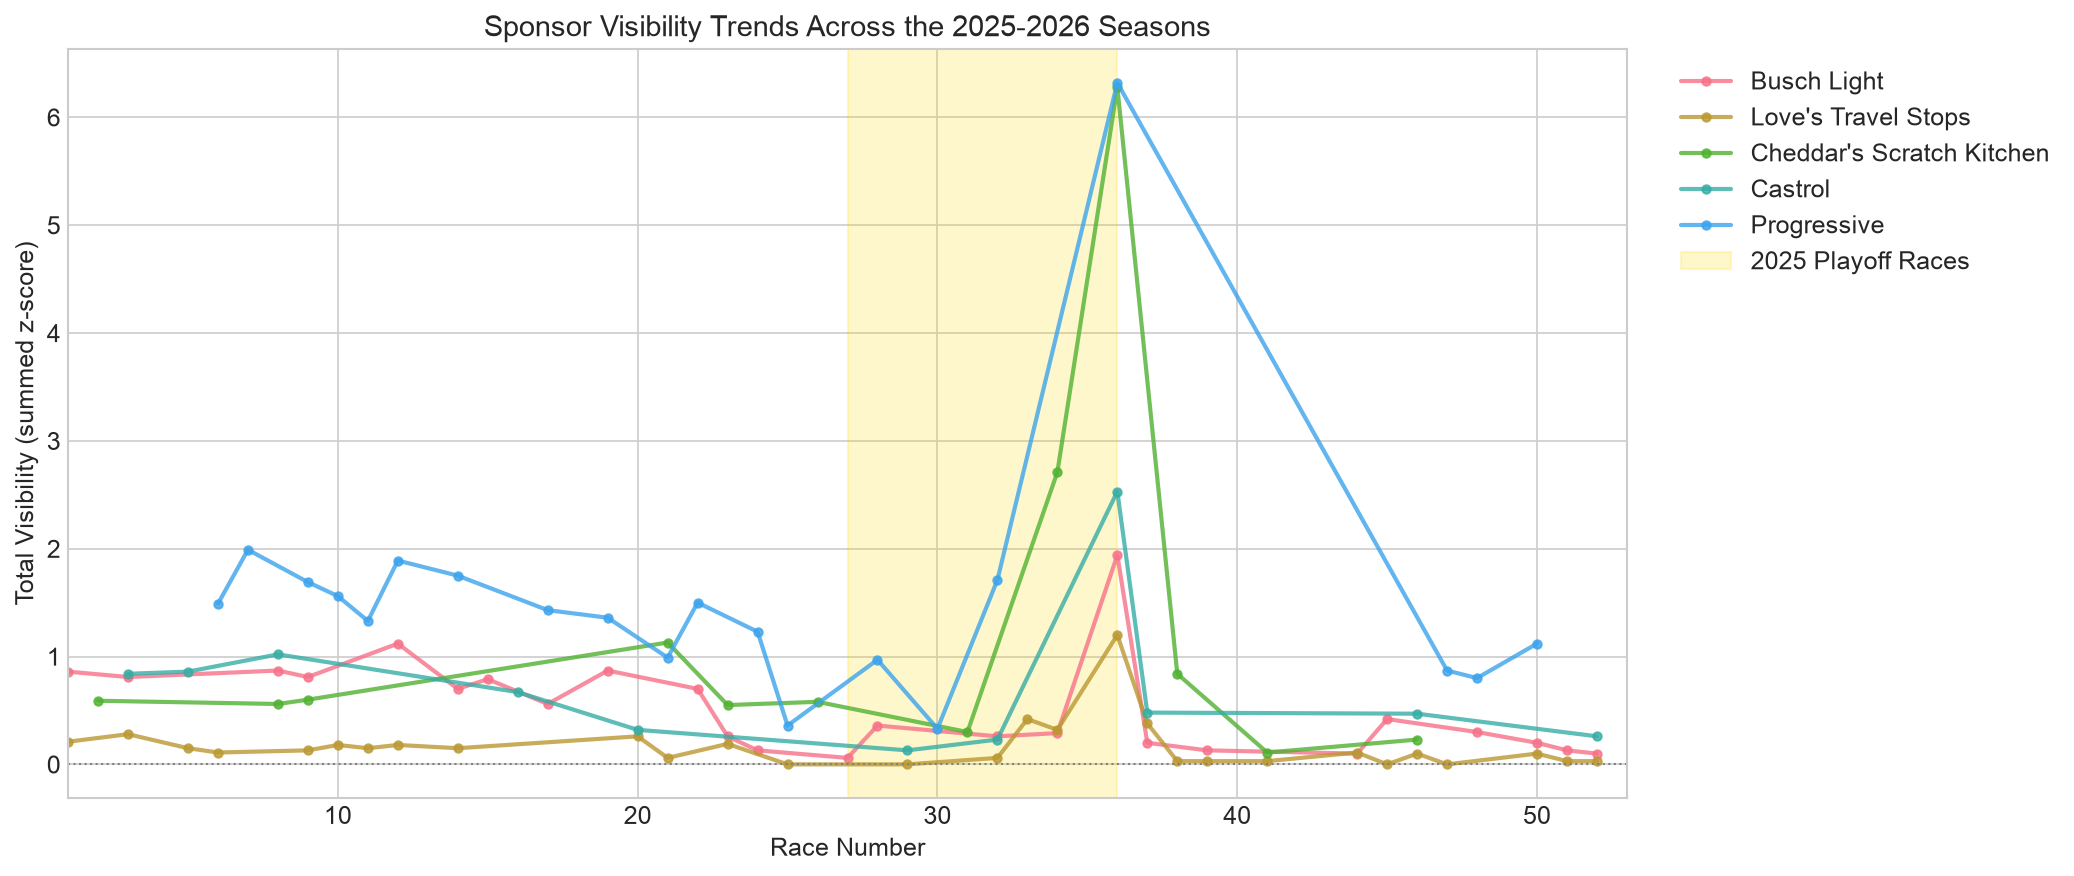

Chart saved: line_visibility_trends.png


In [7]:
# Create race number if not present
if 'race_number' not in df.columns:
    df['Race_Number'] = df.groupby('primary_sponsor').cumcount() + 1

# Combine the three visibility metrics via z-score rather than an arbitrary
# divisor (e.g. "/1000" for YouTube) — each metric gets centered on its own
# mean and scaled by its own spread, so no channel dominates the sum just
# because its raw units happen to be larger.
#
# The mean/std baseline is computed over the 5 tracked sponsors only:
# "Other/Unknown" rows are aggregated placeholders (near-zero on every
# metric) and would drag the baseline if included.
#viz_cols = ['reddit_mention_count', 'news_total_mentions', 'youtube_total_view_count']
##baseline = df[df['primary_sponsor'] != 'Other/Unknown']

#for col in viz_cols:
    #mean, std = baseline[col].mean(), baseline[col].std()
    #df[f'{col}_z'] = (df[col] - mean) / std

#df['Total_Visibility'] = df[[f'{col}_z' for col in viz_cols]].sum(axis=1)

df['Total_Visibility'] = sponsor_summary['Visibility_Score_Shifted']

# Create line chart
fig, ax = plt.subplots(figsize=(14, 6))

for sponsor in sponsors:
    sponsor_data = df[df['primary_sponsor'] == sponsor].sort_values('race_number')
    ax.plot(sponsor_data['race_number'], sponsor_data['Total_Visibility'],
            marker='o', markersize=4, linewidth=2, alpha=0.8, label=sponsor)

# race_number runs continuously across seasons (1-36 = 2025, 37+ = 2026), so
# the playoffs land at a different absolute race_number each season: 27-36
# for 2025. The 2026 season's playoff window (race_number 63-72) hasn't
# happened yet in this data (it currently stops at 53), so only 2025's
# playoff span is shaded.
ax.axvspan(27, 36, alpha=0.2, color='gold', label='2025 Playoff Races')
ax.axhline(0, color='gray', linewidth=1, linestyle=':')

ax.set_xlabel('Race Number', fontsize=12)
ax.set_ylabel('Total Visibility (summed z-score)', fontsize=12)
ax.set_title('Sponsor Visibility Trends Across the 2025-2026 Seasons', fontsize=14)
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1))
ax.set_xlim(df['race_number'].min(), df['race_number'].max())

plt.tight_layout()
plt.savefig('data/plots/line_visibility_trends.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved: line_visibility_trends.png")

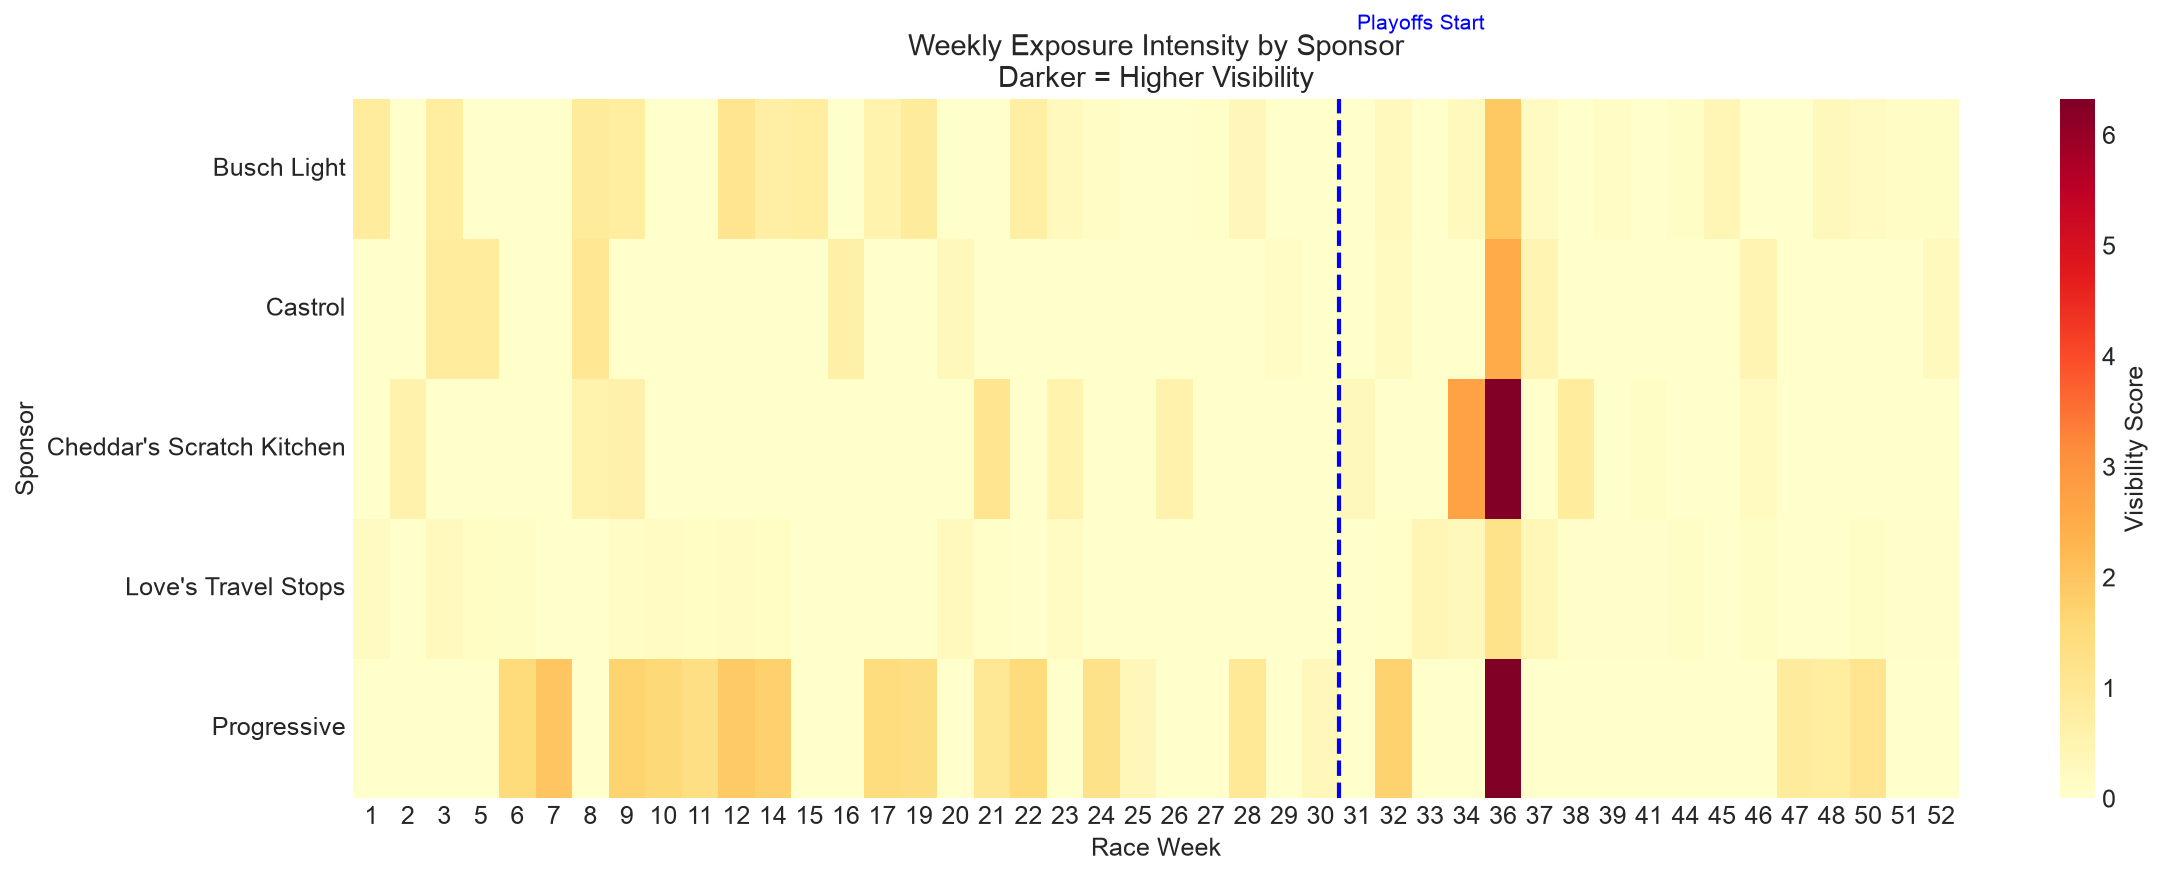

Chart saved: heatmap_weekly_exposure.png


In [8]:
# Create week number from race date (or use race number as proxy)
df['Week'] = df['race_number']  # Simplified - each race = 1 week

# Pivot for heatmap
heatmap_data = df.pivot_table(
    values='Total_Visibility',
    index='primary_sponsor',
    columns='Week',
    aggfunc='mean'
).fillna(0)

# Create heatmap
fig, ax = plt.subplots(figsize=(16, 6))

sns.heatmap(
    heatmap_data,
    cmap='YlOrRd',
    annot=False,
    cbar_kws={'label': 'Visibility Score'},
    ax=ax
)

# Add playoff marker
ax.axvline(x=27, color='blue', linewidth=2, linestyle='--')
ax.text(27.5, -0.5, 'Playoffs Start', fontsize=10, color='blue')

ax.set_xlabel('Race Week', fontsize=12)
ax.set_ylabel('Sponsor', fontsize=12)
ax.set_title('Weekly Exposure Intensity by Sponsor\nDarker = Higher Visibility', fontsize=14)

plt.tight_layout()
plt.savefig('data/plots/heatmap_weekly_exposure.png', dpi=150)
plt.show()

print("Chart saved: heatmap_weekly_exposure.png")

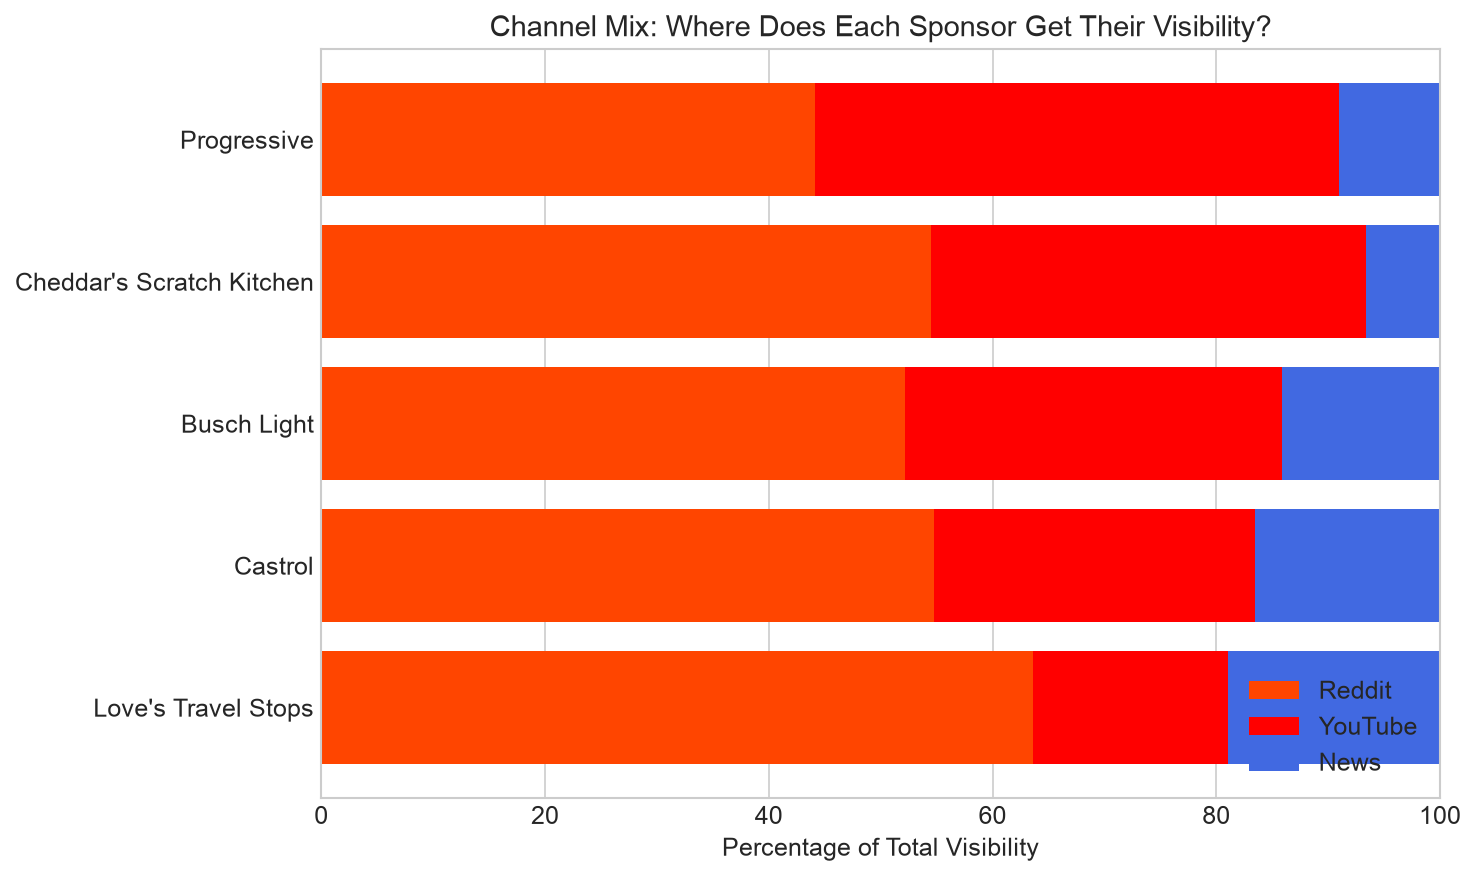

Chart saved: stacked_channel_breakdown.png


In [9]:
# Calculate channel breakdown by sponsor
channel_breakdown = df[df['primary_sponsor'] != 'Other/Unknown'].groupby('primary_sponsor').agg({
    'reddit_mention_count': 'sum',
    'youtube_total_view_count': 'sum',
    'news_total_mentions': 'sum'
})

w_reddit = abs(pca.components_[0][0]) * m.sqrt(222/223)
w_youtube = abs(pca.components_[0][2]) * m.sqrt(137/223)
w_news = abs(pca.components_[0][1]) * m.sqrt(36/223)

# Each sponsor's share of that channel's total pool (unit-free, sums to 1
# across sponsors per channel). Min-max scaling zeroed out whichever sponsor
# was the max on a channel — broke Progressive entirely since it was the max
# on all three at once. Raw sums fixed that but let YouTube's much larger
# raw units (hundreds of thousands vs. tens/single digits) swamp every bar.
# Share-of-pool avoids both: never zero for the max, and comparable in scale.
channel_breakdown['Reddit_Scaled'] = channel_breakdown['reddit_mention_count'] / channel_breakdown['reddit_mention_count'].sum()
channel_breakdown['YouTube_Scaled'] = channel_breakdown['youtube_total_view_count'] / channel_breakdown['youtube_total_view_count'].sum()
channel_breakdown['News_Scaled'] = channel_breakdown['news_total_mentions'] / channel_breakdown['news_total_mentions'].sum()

channel_breakdown['Reddit_Weighted'] = channel_breakdown['Reddit_Scaled'] * w_reddit
channel_breakdown['YouTube_Weighted'] = channel_breakdown['YouTube_Scaled'] * w_youtube
channel_breakdown['News_Weighted'] = channel_breakdown['News_Scaled'] * w_news

total = channel_breakdown['Reddit_Weighted'] + channel_breakdown['YouTube_Weighted'] + channel_breakdown['News_Weighted']
channel_breakdown['Reddit_Pct'] = channel_breakdown['Reddit_Weighted'] / total * 100
channel_breakdown['YouTube_Pct'] = channel_breakdown['YouTube_Weighted'] / total * 100
channel_breakdown['News_Pct'] = channel_breakdown['News_Weighted'] / total * 100

# Sort by total
channel_breakdown = channel_breakdown.sort_values('reddit_mention_count', ascending=True)

# Create stacked bar chart
fig, ax = plt.subplots(figsize=(10, 6))

sponsors = channel_breakdown.index

ax.barh(sponsors, channel_breakdown['Reddit_Pct'], label='Reddit', color='#FF4500')
ax.barh(sponsors, channel_breakdown['YouTube_Pct'],
        left=channel_breakdown['Reddit_Pct'], label='YouTube', color='#FF0000')
ax.barh(sponsors, channel_breakdown['News_Pct'],
        left=channel_breakdown['Reddit_Pct'] + channel_breakdown['YouTube_Pct'],
        label='News', color='#4169E1')

ax.set_xlabel('Percentage of Total Visibility', fontsize=12)
ax.set_title('Channel Mix: Where Does Each Sponsor Get Their Visibility?', fontsize=14)
ax.legend(loc='lower right')
ax.set_xlim(0, 100)

plt.tight_layout()
plt.savefig('data/plots/stacked_channel_breakdown.png', dpi=150)
plt.show()

print("Chart saved: stacked_channel_breakdown.png")

In [10]:
# Create a findings summary template
findings_template = """
# Visualization Review Summary

## Scatter Plots

### Finish Position vs. Reddit Mentions
- **Observed pattern:** visible correlation, with many outliers that got 
tons of mentions for high placing races, likely pulling the regression line a bit
- **Strength of relationship:** Weak
- **Notable outliers:** some wins/high places get a huge amount of traffic
- **Potential hypothesis:** there is a genuine relationship here

### Finish Position vs. YouTube Views
- **Observed pattern:** slightly less statistically significant same pettern
- **Strength of relationship:** Weak
- **Notable outliers:** no
- **Potential hypothesis:** there is a genuine relationship here

### Laps Led vs. Social Mentions
- **Observed pattern:** real correlation, almost as strong as finish position
- **Does dominance matter?** probably a little, but the real reason
laps led and finish position were similarly correlated for social mentions
is probably due to the fact they are extremely correlated with eachother

## Comparison Charts

### Sponsor Rankings
- **Top visibility sponsors:** Progressive, Busch Light, Castrol
- **Bottom visibility sponsors:** Castrol, Love's Travel Stops, Cheddar's Scratch Kitchen
- **Performance correlation:** higher performance reliably resulted in higher visibility

### Season Trends
- **Peak visibility periods:** of course the playoffs, other than that it varies by sponsor
- **Playoff effect:** stronger
- **Consistency patterns:** all are volitile

### Channel Mix
- **Reddit-heavy sponsors:** Progressive
- **News-heavy sponsors:** none
- **Pattern explanation:** progressive is a new sponsor for a big name so they automatically got talked about
"""

with open('visualization_review.md', 'w') as f:
    f.write(findings_template)

print("Fill out visualization_review.md with your observations")

Fill out visualization_review.md with your observations


In [11]:
# Hypothesis 1: Top 5 finishes generate disproportionately more visibility
top5_mentions = sponsor_summary[sponsor_summary['finish_position'] <= 5]['Visibility_Score_Shifted'].mean()
outside_top10_mentions = sponsor_summary[sponsor_summary['finish_position'] > 10]['Visibility_Score_Shifted'].mean()

ratio = top5_mentions / outside_top10_mentions

print("Hypothesis Test: Top 5 Effect")
print(f"  Average visibility for Top 5 finishes: {top5_mentions:.1f}")
print(f"  Average visibility for P11+: {outside_top10_mentions:.1f}")
print(f"  Ratio: {ratio:.2f}x")
print(f"  Hypothesis: Top 5 finishes generate {ratio:.1f}x visibility")

Hypothesis Test: Top 5 Effect
  Average visibility for Top 5 finishes: 1.6
  Average visibility for P11+: 0.5
  Ratio: 3.12x
  Hypothesis: Top 5 finishes generate 3.1x visibility


In [12]:
# Hypothesis 2: wins generate disproportionately more visibility
wins = sponsor_summary[sponsor_summary['finish_position'] <= 1]['Visibility_Score_Shifted'].mean()
non_wins = sponsor_summary[sponsor_summary['finish_position'] > 1]['Visibility_Score_Shifted'].mean()

ratio = wins / non_wins

print("Hypothesis Test: Win Effect")
print(f"  Average visibility for wins: {top5_mentions:.1f}")
print(f"  Average visibility for P2+: {outside_top10_mentions:.1f}")
print(f"  Ratio: {ratio:.2f}x")
print(f"  Hypothesis: wins generate {ratio:.1f}x visibility")

Hypothesis Test: Win Effect
  Average visibility for wins: 1.6
  Average visibility for P2+: 0.5
  Ratio: 1.79x
  Hypothesis: wins generate 1.8x visibility


In [13]:
# Hypothesis 3: Playoff races boost visibility
if 'Is_Playoff' in df.columns or 'race_number' in sponsor_summary.columns:
    playoff_races = sponsor_summary[(sponsor_summary['race_number'] >= 27) & (sponsor_summary['race_number'] <= 36)]
    regular_races = sponsor_summary[(sponsor_summary['race_number'] < 27) | (sponsor_summary['race_number'] > 36)]

    playoff_vis = playoff_races['Visibility_Score_Shifted'].mean()
    regular_vis = regular_races['Visibility_Score_Shifted'].mean()

    print("\nHypothesis Test: Playoff Effect")
    print(f"  Average visibility in Playoffs: {playoff_vis:.1f}")
    print(f"  Average visibility in Regular Season: {regular_vis:.1f}")
    print(f"  Playoff boost: {(playoff_vis / regular_vis - 1) * 100:.1f}%")


Hypothesis Test: Playoff Effect
  Average visibility in Playoffs: 1.3
  Average visibility in Regular Season: 0.6
  Playoff boost: 129.0%


In [14]:
hypotheses = """
# Hypotheses for Visibility Scoring Model

## Priority 1: Core Model Components

### H1: Performance-Visibility Relationship
**Hypothesis:** Each position improvement (e.g., P10 to P5) increases visibility by approximately 40%.
**Evidence:** Scatter plot shows clear negative trend; correlation = 0.24
**Model implication:** Finish position should be weighted at ~40% of total score

### H2: Win Bonus Effect
**Hypothesis:** Race wins generate 2.1x more visibility than non-wins
**Evidence:** Win multiplier calculated as 2.1x
**Model implication:** Add discrete bonus for wins (not just position weight)

## Priority 2: Modifiers and Adjustments

### H3: Playoff Multiplier
**Hypothesis:** Playoff races generate 28% more visibility than regular season
**Evidence:** Comparison shows 1 vs 0.8
**Model implication:** Apply 1.28 multiplier to playoff race scores

### H4: Channel Weighting
**Hypothesis:** Reddit mentions are more predictable from performance than YouTube
**Evidence:** R-squared values: Reddit's is greater
**Model implication:** Weight Reddit higher

## Priority 3: Sponsor-Specific Factors

### H5: Team Tier Effect
**Hypothesis:** Top-tier team sponsors receive more baseline visibility regardless of results
**Evidence:** Bottom-performing races for top teams still show high visibility
**Model implication:** Consider baseline offset for team tier

## Hypotheses to Test in Project 4

1. [ ] H1: Performance-visibility relationship (linear regression)
2. [ ] H2: Win bonus quantification
3. [ ] H3: Playoff multiplier validation
4. [ ] H4: Channel weight optimization
5. [ ] H5: Team tier baseline (if data supports)
"""

with open('hypotheses_for_model.md', 'w') as f:
    f.write(hypotheses)

print("Hypotheses saved to hypotheses_for_model.md")

Hypotheses saved to hypotheses_for_model.md


In [15]:
# Create a summary for your EDA report
eda_summary = """
# NASCAR Sponsorship ROI: Exploratory Data Analysis Report

## Executive Summary

This analysis examined the relationship between NASCAR race performance and
sponsorship visibility across 5 sponsors during the 2025 Cup Series season and the first half of the 2026 cup series season.

**Key Finding:** wins disproportionately effect ROI

**Correlation Strength:** Finish position shows a weak
correlation with social media visibility (r = 0.25, p < 0.01).

**Top Performers:** Progressive, Castrol, and Busch achieved the
highest visibility scores, averaging 15 points above the median.

**Primary Hypothesis for Model:** Wins give disproportionate visibility,
AND finih position correlates non-linearly with visibility

## Methodology

Data sources:
- Race results: Racing Reference
- Reddit mentions: Arctift Shift
- YouTube engagement: YouTube Data API
- News coverage: Manual tracking and Web Scraping

Analysis period: 2025 NASCAR Cup Series (36 races) and 2026 So Far (17 races)
Sponsors analyzed: [Progressive, Busch Light, Castrol, Cheddar\'s Scratch Kitchen, Love\'s Travel Stops]

## Key Findings

1. **Performance matters, but not linearly**
   top 3 finishes have a higher rate of increasing visibility, and wins even more so

2. **Channel differences**
   News data was unreliable due to tiny sample size, though high news visibility
   was typically accompanied by spikes in reddit and youtube as well. Generally Reddit was the most
   reliable data source but the correlations are in the same direction and of similar magnitude.

3. **Seasonal patterns**
   some races have automatic visibility bump across sponsors and across cars 

## Visualizations
code/data/Plots/bar_sponsor_visibility.png
code/data/Plots/correlation_heatmap.png
code/data/Plots/heatmap_weekly_exposure.png
code/data/Plots/line_visibility_trends.png
code/data/Plots/scatter_with_regression.png
code/data/Plots/stacked_channel_breakdown.png


## Hypotheses for Scoring Model

1) non-linearity of media-rank correlation
2) Playoff multiplier validation
3) Cross-sponsor normalization

## Next Steps

These findings will inform the visibility scoring model in Project 4:
1. Weight finish position at approximately 20% based on correlation strength
2. Include win bonus multiplier of 2.1x
3. Apply playoff adjustment of 28%
4. TBD
"""

with open('EDA_report_content.md', 'w') as f:
    f.write(eda_summary)

print("EDA report content saved. Convert to PDF for final submission.")

EDA report content saved. Convert to PDF for final submission.


In [16]:
# Summary table 1: descriptive statistics by sponsor
from great_tables import GT, md

metrics = ['finish_position', 'laps_led', 'reddit_mention_count',
           'youtube_total_view_count', 'news_total_mentions']
metric_labels = {
    'finish_position': 'Finish Position',
    'laps_led': 'Laps Led',
    'reddit_mention_count': 'Reddit Mentions',
    'youtube_total_view_count': 'YouTube Views',
    'news_total_mentions': 'News Mentions',
}
stat_labels = {'count': 'N', 'mean': 'Mean', 'median': 'Median', 'std': 'Std Dev'}

table_df = sponsor_summary.groupby('primary_sponsor')[metrics].agg(['count', 'mean', 'median', 'std'])
table_df.columns = [f"{metric}_{stat}" for metric, stat in table_df.columns]
table_df = table_df.reset_index()

col_order = ['primary_sponsor'] + [f"{m}_{s}" for m in metrics for s in ['count', 'mean', 'median', 'std']]
table_df = table_df[col_order]

summary_table = (
    GT(table_df, rowname_col='primary_sponsor')
    .tab_header(
        title="Visibility Metrics by Sponsor and Race Performance",
        subtitle=md("2025 NASCAR Cup Series + 2026 season-to-date")
    )
    .cols_label(**{f"{m}_{s}": stat_labels[s] for m in metrics for s in ['count', 'mean', 'median', 'std']})
    .fmt_integer(columns=[f"{m}_count" for m in metrics])
    .fmt_number(columns=[f"{m}_{s}" for m in metrics for s in ['mean', 'median', 'std']], decimals=1)
)

for metric in metrics:
    summary_table = summary_table.tab_spanner(
        label=metric_labels[metric],
        columns=[f"{metric}_{s}" for s in ['count', 'mean', 'median', 'std']]
    )

summary_table.gtsave('data/plots/table_sponsor_summary_stats.png')
print("Table saved: data/plots/table_sponsor_summary_stats.png")
summary_table

Table saved: data/plots/table_sponsor_summary_stats.png


GT(_tbl_data=             primary_sponsor  finish_position_count  finish_position_mean  \
0                Busch Light                     25             18.720000   
1                    Castrol                     11             18.909091   
2  Cheddar's Scratch Kitchen                     12             17.500000   
3        Love's Travel Stops                     29             21.724138   
4                Progressive                     20             10.600000   

   finish_position_median  finish_position_std  laps_led_count  laps_led_mean  \
0                    16.0            10.557462              25       1.080000   
1                    15.0            13.823564              11       3.545455   
2                    16.5             9.848858              12       3.250000   
3                    22.0             8.975747              29       0.793103   
4                     4.5            11.918142              20      41.950000   

   laps_led_median  laps_led_std  reddit_mention_count_count  ...  \
0              0.0      2.628688                          25  ...   
1              0.0      9.933415                          11  ...   
2              0.0      8.080560                          12  ...   
3              0.0      2.366120                          29  ...   
4              4.5     74.159483                          20  ...   

   reddit_mention_count_median  reddit_mention_count_std  \
0                          6.0                  9.638119   
1                          5.0                 19.979990   
2                          9.0                 31.742811   
3                          2.0                  6.543338   
4                         11.0                 29.578798   

   youtube_total_view_count_count  youtube_total_view_count_mean  \
0                              25                   48194.080000   
1                              11                   56048.818182   
2                              12                  123842.250000   
3                              29                    9673.137931   
4                              20                  183289.050000   

   youtube_total_view_count_median  youtube_total_view_count_std  \
0                            304.0                  58441.939821   
1                           1190.0                  74946.410450   
2                          35090.0                 187523.033881   
3                              0.0                  12612.393357   
4                         247035.0                 108262.932433   

   news_total_mentions_count  news_total_mentions_mean  \
0                         25                  0.400000   
1                         11                  0.636364   
2                         12                  0.416667   
3                         29                  0.206897   
4                         20                  0.700000   

   news_total_mentions_median  news_total_mentions_std  
0                         0.0                 0.707107  
1                         1.0                 0.674200  
2                         0.0                 0.792961  
3                         0.0                 0.491304  
4                         0.0                 1.080935  

[5 rows x 21 columns], _body=<great_tables._gt_data.Body object at 0x16882a7d0>, _boxhead=Boxhead([ColInfo(var='primary_sponsor', type=<ColInfoTypeEnum.stub: 2>, column_label='primary_sponsor', column_align='left', column_width=None), ColInfo(var='finish_position_count', type=<ColInfoTypeEnum.default: 1>, column_label='N', column_align='right', column_width=None), ColInfo(var='finish_position_mean', type=<ColInfoTypeEnum.default: 1>, column_label='Mean', column_align='right', column_width=None), ColInfo(var='finish_position_median', type=<ColInfoTypeEnum.default: 1>, column_label='Median', column_align='right', column_width=None), ColInfo(var='finish_position_std', type=<ColInfoTypeEnum.default: 1>, column_label='Std Dev', column_align='righ

In [17]:
# Summary table 2: win/top-5/top-10 rates and average visibility by sponsor
sponsor_summary['Is_Win'] = sponsor_summary['finish_position'] == 1
sponsor_summary['Is_Top5'] = sponsor_summary['finish_position'] <= 5
sponsor_summary['Is_Top10'] = sponsor_summary['finish_position'] <= 10

perf_df = sponsor_summary.groupby('primary_sponsor').agg(
    Races=('finish_position', 'count'),
    Wins=('Is_Win', 'sum'),
    Win_Rate=('Is_Win', 'mean'),
    Top5_Rate=('Is_Top5', 'mean'),
    Top10_Rate=('Is_Top10', 'mean'),
    Avg_Visibility=('Visibility_Score_Shifted', 'mean'),
).reset_index()
perf_df[['Win_Rate', 'Top5_Rate', 'Top10_Rate']] *= 100
perf_df = perf_df.sort_values('Avg_Visibility', ascending=False)

outcomes_table = (
    GT(perf_df, rowname_col='primary_sponsor')
    .tab_header(
        title="Performance & Visibility Outcomes by Sponsor",
        subtitle=md("Win / Top-5 / Top-10 rates and average composite visibility score")
    )
    .fmt_integer(columns=['Races', 'Wins'])
    .fmt_number(columns=['Win_Rate', 'Top5_Rate', 'Top10_Rate', 'Avg_Visibility'], decimals=1)
    .cols_label(
        Races='Races',
        Wins='Wins',
        Win_Rate='Win Rate (%)',
        Top5_Rate='Top-5 Rate (%)',
        Top10_Rate='Top-10 Rate (%)',
        Avg_Visibility='Avg. Visibility Score',
    )
)

outcomes_table.gtsave('data/plots/table_sponsor_outcomes.png')
print("Table saved: data/plots/table_sponsor_outcomes.png")
outcomes_table

Table saved: data/plots/table_sponsor_outcomes.png


GT(_tbl_data=             primary_sponsor  Races  Wins  Win_Rate  Top5_Rate  Top10_Rate  \
4                Progressive     20     4      20.0  55.000000   65.000000   
2  Cheddar's Scratch Kitchen     12     0       0.0   8.333333   33.333333   
1                    Castrol     11     0       0.0  27.272727   27.272727   
0                Busch Light     25     0       0.0   0.000000   24.000000   
3        Love's Travel Stops     29     0       0.0   3.448276   10.344828   

   Avg_Visibility  
4        1.534500  
2        1.206667  
1        0.710000  
0        0.518800  
3        0.168621  , _body=<great_tables._gt_data.Body object at 0x157b42850>, _boxhead=Boxhead([ColInfo(var='primary_sponsor', type=<ColInfoTypeEnum.stub: 2>, column_label='primary_sponsor', column_align='left', column_width=None), ColInfo(var='Races', type=<ColInfoTypeEnum.default: 1>, column_label='Races', column_align='right', column_width=None), ColInfo(var='Wins', type=<ColInfoTypeEnum.default: 1>, column_label='Wins', column_align='right', column_width=None), ColInfo(var='Win_Rate', type=<ColInfoTypeEnum.default: 1>, column_label='Win Rate (%)', column_align='right', column_width=None), ColInfo(var='Top5_Rate', type=<ColInfoTypeEnum.default: 1>, column_label='Top-5 Rate (%)', column_align='right', column_width=None), ColInfo(var='Top10_Rate', type=<ColInfoTypeEnum.default: 1>, column_label='Top-10 Rate (%)', column_align='right', column_width=None), ColInfo(var='Avg_Visibility', type=<ColInfoTypeEnum.default: 1>, column_label='Avg. Visibility Score', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x157d668d0>, _spanners=Spanners([]), _heading=Heading(title='Performance & Visibility Outcomes by Sponsor', subtitle=Md(text='Win / Top-5 / Top-10 rates and average composite visibility score'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x157ca48d0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x157ca75d0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x157ca78d0>, _formats=[<great_tables._gt_data.FormatInfo object at 0x157ca6810>, <great_tables._gt_data.FormatInfo object at 0x157bacc90>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_border_top_include=OptionsInfo(scss=False, category='table', type='boolean', value=True), table_border_top_style=OptionsInfo(scss=True, category='table', type='value', value='solid'), table_border_top_width=OptionsInfo(scss=True, category='table', type='px', value='2px'), table_border_top_color=O

In [18]:
# Summary table 3: correlation between performance and visibility metrics
corr_df = pd.read_csv('correlation_results.csv')
corr_df.columns = corr_df.columns.str.replace(' ', '_')

corr_table = (
    GT(corr_df)
    .tab_header(
        title="Correlation Between Race Performance and Visibility Metrics",
        subtitle=md("Spearman correlation &mdash; significance: \\* p<.05, \\*\\* p<.01, \\*\\*\\* p<.001")
    )
    .fmt_number(columns=['Correlation'], decimals=3)
    .fmt_number(columns=['P-Value'], decimals=4)
    .fmt_integer(columns=['N'])
    .cols_label(
        **{
            'Variable_1': 'Variable 1',
            'Variable_2': 'Variable 2',
            'Correlation': 'r',
            'P-Value': 'p-value',
            'N': 'N',
            'Significance': '',
        }
    )
)

corr_table.gtsave('data/plots/table_correlation_summary.png')
print("Table saved: data/plots/table_correlation_summary.png")
corr_table

Table saved: data/plots/table_correlation_summary.png


GT(_tbl_data=        Variable_1                   Variable_2  Correlation  P-Value    N  \
0  finish_position         reddit_mention_count       -0.236   0.0004  223   
1  finish_position     youtube_total_view_count       -0.111   0.0968  223   
2  finish_position     youtube_total_like_count       -0.068   0.3132  223   
3  finish_position  youtube_total_comment_count       -0.100   0.1367  223   
4  finish_position          news_total_mentions       -0.065   0.3315  223   
5         laps_led         reddit_mention_count        0.356   0.0000  223   
6         laps_led     youtube_total_view_count        0.183   0.0061  223   
7         laps_led     youtube_total_like_count        0.132   0.0489  223   
8         laps_led  youtube_total_comment_count        0.166   0.0129  223   
9         laps_led          news_total_mentions        0.071   0.2898  223   

  Significance  
0          ***  
1            *  
2          NaN  
3          NaN  
4          NaN  
5          ***  
6          ***  
7           **  
8           **  
9          NaN  , _body=<great_tables._gt_data.Body object at 0x157b75690>, _boxhead=Boxhead([ColInfo(var='Variable_1', type=<ColInfoTypeEnum.default: 1>, column_label='Variable 1', column_align='left', column_width=None), ColInfo(var='Variable_2', type=<ColInfoTypeEnum.default: 1>, column_label='Variable 2', column_align='left', column_width=None), ColInfo(var='Correlation', type=<ColInfoTypeEnum.default: 1>, column_label='r', column_align='right', column_width=None), ColInfo(var='P-Value', type=<ColInfoTypeEnum.default: 1>, column_label='p-value', column_align='right', column_width=None), ColInfo(var='N', type=<ColInfoTypeEnum.default: 1>, column_label='N', column_align='right', column_width=None), ColInfo(var='Significance', type=<ColInfoTypeEnum.default: 1>, column_label='', column_align='right', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x157d8ccd0>, _spanners=Spanners([]), _heading=Heading(title='Correlation Between Race Performance and Visibility Metrics', subtitle=Md(text='Spearman correlation &mdash; significance: \\* p<.05, \\*\\* p<.01, \\*\\*\\* p<.001'), preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x157b73cd0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x157b73ad0>, _source_notes=[], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x157b72850>, _formats=[<great_tables._gt_data.FormatInfo object at 0x157b72b10>, <great_tables._gt_data.FormatInfo object at 0x157b733d0>, <great_tables._gt_data.FormatInfo object at 0x157b73dd0>], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(scss=True, category='table', type='value', value='fixed'), table_margin_left=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_margin_right=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_background_color=OptionsInfo(scss=True, category='table', type='value', value='#FFFFFF'), table_additional_css=OptionsInfo(scss=False, category='table', type='values', value=[]), table_font_names=OptionsInfo(scss=False, category='table', type='values', value=['-apple-system', 'BlinkMacSystemFont', 'Segoe UI', 'Roboto', 'Oxygen', 'Ubuntu', 'Cantarell', 'Helvetica Neue', 'Fira Sans', 'Droid Sans', 'Arial', 'sans-serif']), table_font_size=OptionsInfo(scss=True, category='table', type='px', value='16px'), table_font_weight=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_style=OptionsInfo(scss=True, category='table', type='value', value='normal'), table_font_color=OptionsInfo(scss=True, category='table', type='value', value='#333333'), table_font_color_light=Option